# 08 — Windowed 3D Tensors

**Vignette index:** | [`01` GKMKernel basics](01_basic_kernel_matrix.ipynb) | [`02` Distance metrics & kernels](02_distance_metrics_and_kernels.ipynb) | [`03` SVM with kernel](03_svc_with_kernel.ipynb) | [`04` Clustering](04_clustering_sequences.ipynb) | [`05` Long sequence scoring](05_score_long_sequence.ipynb) | [`06` Weighted (WGKM) kernel](06_weighted_kernel.ipynb) | [`07` Transforms & comparison](07_transform_and_comparison.ipynb) | `**08**` Windowed 3D tensors | [`09` Spectrum encoder & NB](09_spectrum_encoder_and_differential.ipynb) | [`10` Gappy encoder](10_gappy_encoder.ipynb) | [`11` Mismatch encoder](11_mismatch_encoder.ipynb) | [`12` Shuffler & chunker](12_shuffler_and_chunker.ipynb)

`WindowedGKMKernel` produces a 3D tensor of shape `(n_windows, n_sequences, n_sequences)`. By tracking the kernel value at each window position, we can see how sequence similarity changes along the sequences.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kmer.kernels import WindowedGKMKernel

seq_a = "ACGTACGTACGT" + "TTTTGGGGCCCC"  # motif at start
seq_b = "TTTTGGGGCCCC" + "ACGTACGTACGT"  # motif at end
seqs = [seq_a, seq_b]

kern = WindowedGKMKernel(L=6, k=4, d=2, window=8, shift=2, padding=0)
kern.set_references(seqs)
T = np.asarray(kern.kernel())
print("Tensor shape:", T.shape)

Tensor shape: (10, 2, 2)


## Line plot of kernel value per window

The diagonal (self-kernel) is constant at 1.0. The off-diagonal (cross-kernel) peaks where the two sequences share a motif in the same window.

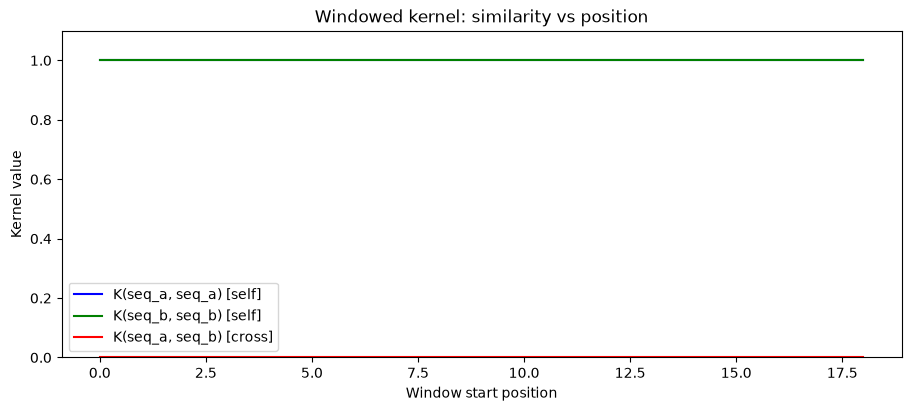

Peak cross-kernel at window position 0


In [2]:
n_windows = T.shape[0]
window_starts = np.arange(n_windows) * 2

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(window_starts, T[:, 0, 0], "b-", label="K(seq_a, seq_a) [self]")
ax.plot(window_starts, T[:, 1, 1], "g-", label="K(seq_b, seq_b) [self]")
ax.plot(window_starts, T[:, 0, 1], "r-", label="K(seq_a, seq_b) [cross]")
ax.set_xlabel("Window start position")
ax.set_ylabel("Kernel value")
ax.set_title("Windowed kernel: similarity vs position")
ax.legend()
ax.set_ylim(0, 1.1)
plt.show()

peak = window_starts[np.argmax(T[:, 0, 1])]
print(f"Peak cross-kernel at window position {peak}")